In [2]:
import zipfile
import os

# Replace 'your_file_name.zip' with the actual name of the file you uploaded
zip_path = '/content/drive/MyDrive/AI & ML/week5/FruitinAmazon.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipping complete.")

# Check the folder structure to find where the 'train' folder is
# Usually it's /content/dataset/train or /content/dataset/NameOfZip/train
!ls /content/dataset

Unzipping complete.
FruitinAmazon


In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from PIL import Image
from sklearn.metrics import classification_report

In [4]:
train_dir = ""
for root, dirs, files in os.walk(extract_path):
    if 'train' in dirs:
        train_dir = os.path.join(root, 'train')
        break

classes = sorted(os.listdir(train_dir))
print(f"Data found at: {train_dir}")
print(f"Detected Classes: {classes}")

Data found at: /content/dataset/FruitinAmazon/train
Detected Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


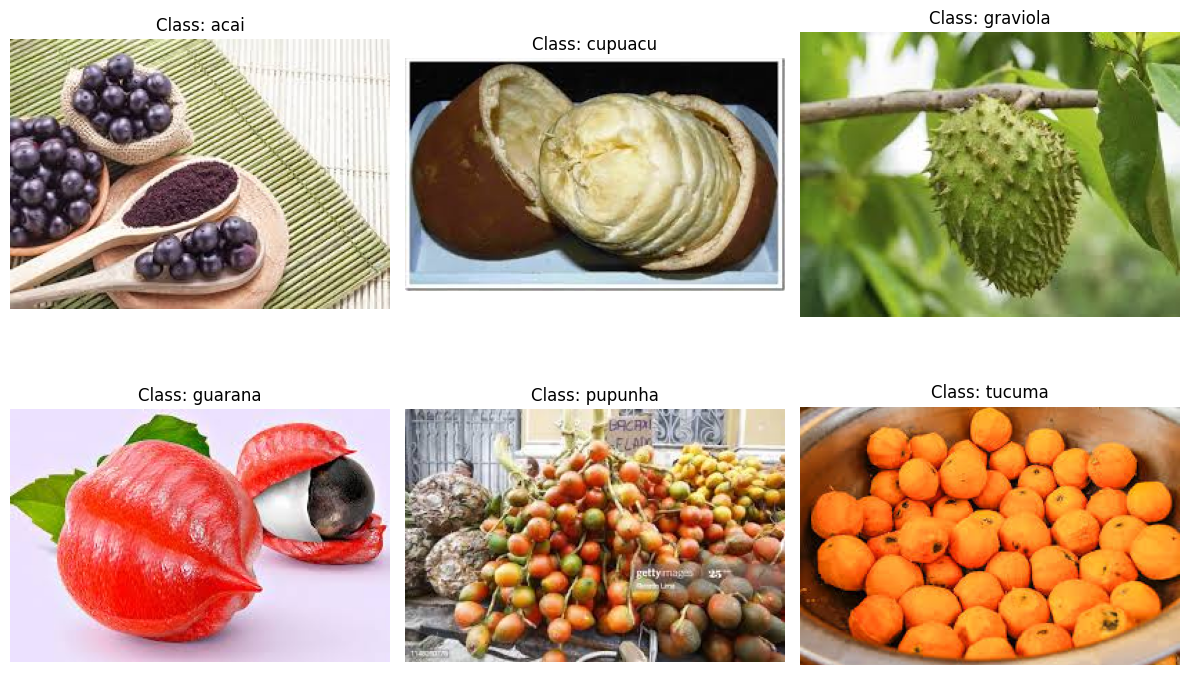

In [5]:
plt.figure(figsize=(12, 8))
for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    image_name = random.choice(os.listdir(class_path))
    img = Image.open(os.path.join(class_path, image_name))

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Class: {class_name}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Observation: We can see distinct visual features for each fruit type.

Task 2: Loading and Preprocessing Image Data


In [6]:
img_height, img_width = 128, 128
batch_size = 32

# Load training data (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='int'
)

# Load validation data (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='int'
)

# Normalization (Scale pixels from 0-255 to 0-1)
rescale = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# GPU Optimization (Mandatory for Colab speed)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


Task 3: Implement CNN Architecture


In [7]:
num_classes = len(classes)

model = keras.Sequential([
    # Convolutional Layer 1: 32 filters, 3x3, same padding
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2, 2), strides=2),

    # Convolutional Layer 2: 32 filters, 3x3, same padding
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    # Fully Connected Layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax') # Output layer
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 4: Compile and Train the Model

In [8]:
# Task 4: Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks to avoid overfitting and save the best version
checkpoint_cb = callbacks.ModelCheckpoint("best_model.h5", save_best_only=True)
early_stopping_cb = callbacks.EarlyStopping(patience=12, restore_best_weights=True)

# Task 4: Train (Set batch_size=16 as per worksheet)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 950ms/step - accuracy: 0.1904 - loss: 2.1884

3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.1806 - loss: 2.3647 - val_accuracy: 0.0556 - val_loss: 2.4427
Epoch 2/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1562 - loss: 2.2521

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.2222 - loss: 2.0346 - val_accuracy: 0.0556 - val_loss: 1.9104
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2778 - loss: 1.7511 - val_accuracy: 0.1667 - val_loss: 1.9539
Epoch 4/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7500 - loss: 1.4404

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.2639 - loss: 1.6783 - val_accuracy: 0.2222 - val_loss: 1.8763
Epoch 5/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8750 - loss: 1.2851

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.3889 - loss: 1.5728 - val_accuracy: 0.0556 - val_loss: 1.8641
Epoch 6/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4375 - loss: 1.5031

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4583 - loss: 1.4462 - val_accuracy: 0.1667 - val_loss: 1.8066
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5972 - loss: 1.2406 - val_accuracy: 0.1667 - val_loss: 1.8103
Epoch 8/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7812 - loss: 1.0859

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8194 - loss: 1.0075 - val_accuracy: 0.3333 - val_loss: 1.7405
Epoch 9/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.7812 - loss: 0.8075

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8333 - loss: 0.7381 - val_accuracy: 0.2778 - val_loss: 1.6298
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8333 - loss: 0.5899 - val_accuracy: 0.2778 - val_loss: 1.7210
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8056 - loss: 0.5074 - val_accuracy: 0.2778 - val_loss: 1.7196
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8056 - loss: 0.5389 - val_accuracy: 0.2222 - val_loss: 2.5452
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9306 - loss: 0.3426 - val_accuracy: 0.2222 - val_loss: 2.1059
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9444 - loss: 0.2303 - val_accuracy: 0.5556 - val_loss: 1.6405
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8889 - loss: 0.2911 - val_accuracy: 0.3889 - val_loss: 1.9291
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0852 - val_accuracy: 0.2778 - val_loss: 1.89

Task 5: Evaluate the Model

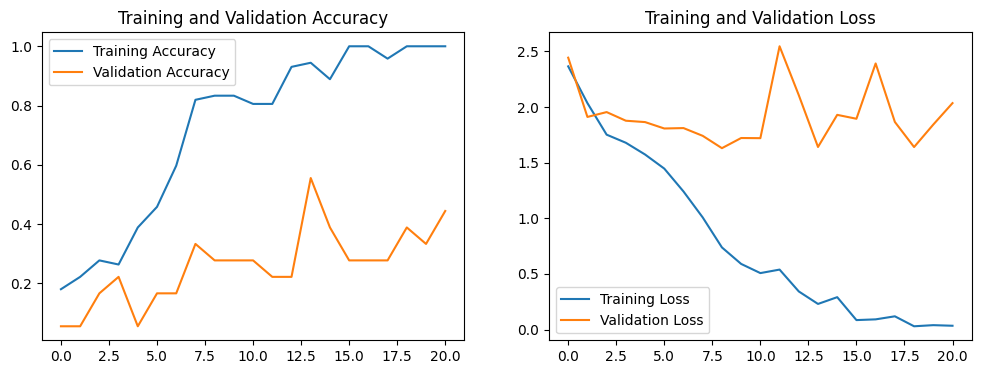

In [11]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

Task 6: Save and Load the Model

In [12]:
# Save
model.save("amazon_fruit_model.h5")
print("Model saved to disk.")

# Load and re-verify
loaded_model = keras.models.load_model("amazon_fruit_model.h5")
loss, accuracy = loaded_model.evaluate(val_ds)
print(f"Reloaded Model Accuracy: {accuracy*100:.2f}%")


Model saved to disk.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 618ms/step - accuracy: 0.2778 - loss: 1.6298
Reloaded Model Accuracy: 27.78%


Task 7: Predictions and Classification Report

In [13]:
y_true = []
y_pred = []

# Loop through the validation dataset to get predictions
for x, y in val_ds:
    predictions = loaded_model.predict(x, verbose=0)
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Generate the report
print("\nFinal Classification Report:")
print(classification_report(y_true, y_pred, target_names=classes))


Final Classification Report:
              precision    recall  f1-score   support

        acai       0.50      1.00      0.67         1
     cupuacu       0.00      0.00      0.00         2
    graviola       0.00      0.00      0.00         3
     guarana       0.33      0.40      0.36         5
     pupunha       0.25      0.25      0.25         4
      tucuma       0.20      0.33      0.25         3

    accuracy                           0.28        18
   macro avg       0.21      0.33      0.26        18
weighted avg       0.21      0.28      0.24        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
